# Chapter 10: Linear regression with multiple predictors

In [14]:
import arviz
import bambi
import numpy
import pandas

from scipy import stats
from matplotlib import pyplot

In [15]:
_BASE_SEED = "Once again back it's the incredible, rhyme animal, unforgettable D chapter tenemy number 1."

def fresh_prng(seed: str):
    return numpy.random.default_rng(seed=abs(hash(_BASE_SEED + seed)) % (2 ** 32))

### 10.1, Regression with interactions

> Simulate 100 data points from the model,
> $y = b_0 + b_1x + b_2z + b_3xz + error$, with a continuous predictor $x$ and a
> binary predictor $z$, coefficients $b = \{1, 2, -1, -2\}$, and errors drawn
> independently from a normal distribution with mean 0 and standard deviation 3,
> as follows. For each data point $i$, first draw $z_i$ , equally likely to
> take on the values 0 and 1. Then draw $x_i$ from a normal distribution with
> mean $z_i$ and standard deviation 1. Then draw the error from its normal
> distribution and compute $y_i$.
> 
> (a) Display your simulated data as a graph of $y$ vs. $x$, using dots and
>     circles for the points with $z = 0$ and $1$, respectively.
>
> (b) Fit a regression predicting $y$ from $x$ and $z$ with no interaction. Make
> a graph with the data and two parallel lines showing the fitted model.
> 
> (c) Fit a regression predicting $y$ from $x$, $z$, and their interaction. Make
> a graph with the data and two lines showing the fitted model.

In [16]:
rng = fresh_prng('Exercise 10.1')

In [17]:
zs = rng.choice(2, size=100)
xs = rng.normal(loc=zs)
ys = rng.normal(loc=(1 + 2 * xs - zs - 2 * xs * zs), scale=3)

In [18]:
ex1_df = pandas.DataFrame(data={'x': xs, 'z': zs, 'y': ys})

In [24]:
model_linear = bambi.Model('y ~ x + z', ex1_df)
fit_linear = model_linear.fit()
summ_linear = arviz.summary(fit_linear, var_names='~mu')
b0_linear = summ_linear['mean']['Intercept']
b1_linear = summ_linear['mean']['x']
b2_linear = summ_linear['mean']['z']
arviz.summary(fit_linear, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.884,0.207,2.519,3.282,0.003,0.003,5096.0,2967.0,1.0
Intercept,0.599,0.425,-0.201,1.415,0.006,0.006,5130.0,3155.0,1.0
x,0.416,0.314,-0.181,0.981,0.005,0.004,3410.0,3316.0,1.0
z,-0.946,0.631,-2.080,0.302,0.010,0.009,4012.0,3193.0,1.0


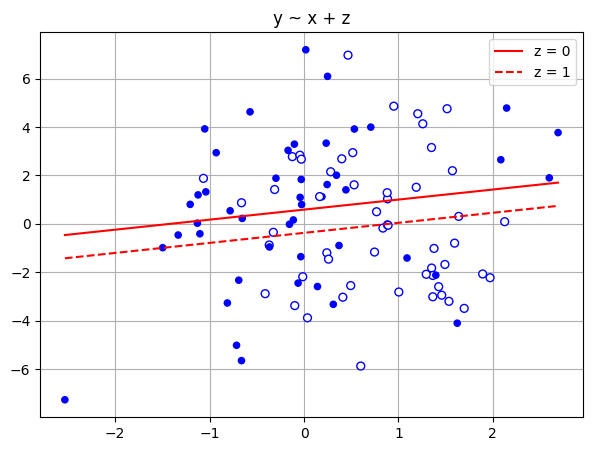

In [20]:
fig = pyplot.figure(figsize=(7, 5))
ax = fig.gca()
ax.grid(zorder=10)
ax.scatter(
    xs,
    ys,
    s=[32 if zi == 1 else 20 for zi in zs],
    c=['w' if zi == 1 else 'b' for zi in zs],
    edgecolors='b',
)
ax.plot(
    [min(xs), max(xs)],
    [b0_linear + b1_linear * min(xs), b0_linear + b1_linear * max(xs)],
    'r-',
    label='z = 0'
)
ax.plot(
    [min(xs), max(xs)],
    [b0_linear + b1_linear * min(xs) + b2_linear, b0_linear + b1_linear * max(xs) + b2_linear],
    'r--',
    label='z = 1'
)
ax.set_title('y ~ x + z')
ax.legend()
ax.set_axisbelow(True)

In [21]:
model_inter = bambi.Model('y ~ x + z + x:z', ex1_df)
fit_inter = model_inter.fit()
summ_inter = arviz.summary(fit_inter, var_names='~mu')
b0_inter = summ_inter['mean']['Intercept']
b1_inter = summ_inter['mean']['x']
b2_inter = summ_inter['mean']['z']
b3_inter = summ_inter['mean']['x:z']
arviz.summary(fit_inter, var_names='~mu')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, x, z, x:z]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(
/home/bgawalt/venv/ros/lib/python3.10/site-packages/arviz/utils.py:146: UserWarning: Items starting with ~: ['mu'] have not been found and will be ignored
  warnings.warn(


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,2.850,0.207,2.490,3.240,0.003,0.004,3861.0,2938.0,1.0
Intercept,0.602,0.424,-0.173,1.401,0.006,0.006,4679.0,3422.0,1.0
x,0.862,0.395,0.074,1.555,0.007,0.006,3654.0,3123.0,1.0
z,-0.334,0.708,-1.704,0.956,0.011,0.010,3961.0,2848.0,1.0
x:z,-1.272,0.646,-2.421,0.025,0.011,0.011,3629.0,2558.0,1.0


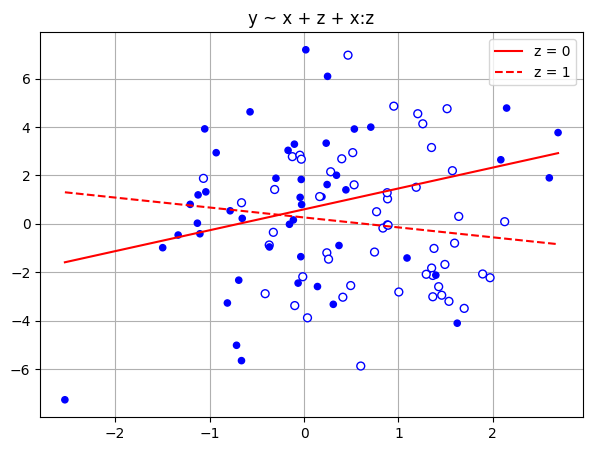

In [23]:
fig = pyplot.figure(figsize=(7, 5))
ax = fig.gca()
ax.grid(zorder=10)
ax.scatter(
    xs,
    ys,
    s=[32 if zi == 1 else 20 for zi in zs],
    c=['w' if zi == 1 else 'b' for zi in zs],
    edgecolors='b',
)
ax.plot(
    [min(xs), max(xs)],
    [b0_inter + b1_inter * min(xs), b0_inter + b1_inter * max(xs)],
    'r-',
    label='z = 0'
)
ax.plot(
    [min(xs), max(xs)],
    [
        b0_inter + (b1_inter + b3_inter) * min(xs) + b2_inter,
        b0_inter + (b1_inter + b3_inter) * max(xs) + b2_inter,
    ],
    'r--',
    label='z = 1'
)
ax.set_title('y ~ x + z + x:z')
ax.legend()
ax.set_axisbelow(True)